<a href="https://colab.research.google.com/github/PankajKhanwariya/PankajKhanwariya/blob/main/Module%201%20Amazon%20E-Commerce%20Data%20Business%20case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [ ]:
customer_df = pd.read_excel('/content/drive/MyDrive/Scaler Datasets/Copy of CustomersData.xlsx') # CustomersData

In [ ]:
discount_df = pd.read_csv('/content/drive/MyDrive/Scaler Datasets/Copy of Discount_Coupon.csv') # Discount_Coupon

In [ ]:
marketingspend_df = pd.read_csv('/content/drive/MyDrive/Scaler Datasets/Copy of Marketing_Spend.csv') # Marketing_Spend

In [ ]:
onlinesales_df = pd.read_csv('/content/drive/MyDrive/Scaler Datasets/Copy of Online_Sales.csv') # Online_Sales

In [ ]:
taxamount_df = pd.read_excel('/content/drive/MyDrive/Scaler Datasets/Copy of Tax_amount.xlsx') # Tax_Amount

# EDA

In [ ]:
print(customer_df.shape)
print(discount_df.shape)
print(marketingspend_df.shape)
print(onlinesales_df.shape)
print(taxamount_df.shape)

(1468, 4)
(204, 4)
(365, 3)
(52924, 10)
(20, 2)


In [ ]:
# Customer data
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   int64 
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.0+ KB


In [ ]:
customer_df['CustomerID'] = customer_df['CustomerID'].astype('object')

In [ ]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1468 entries, 0 to 1467
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1468 non-null   object
 1   Gender         1468 non-null   object
 2   Location       1468 non-null   object
 3   Tenure_Months  1468 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 46.0+ KB


In [ ]:
customer_df.isnull().sum()

,0
CustomerID,0
Gender,0
Location,0
Tenure_Months,0


In [ ]:
# Discount data
discount_df.sample(10)

,Month,Product_Category,Coupon_Code,Discount_pct
12,Jan,Lifestyle,EXTRA10,10
41,Mar,Accessories,ACC30,30
48,Jan,Android,AND10,10
114,Jul,Lifestyle,EXTRA10,10
107,Sep,Nest-USA,ELEC30,30
171,Oct,Notebooks,NOTES10,10
157,Nov,Nest-USA,ELEC20,20
200,Dec,Notebooks & Journals,NJ30,30
23,Mar,Headgear,HGEAR30,30
44,Mar,Gift Cards,GC30,30


In [ ]:
discount_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Month             204 non-null    object
 1   Product_Category  204 non-null    object
 2   Coupon_Code       204 non-null    object
 3   Discount_pct      204 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 6.5+ KB


In [ ]:
discount_df['Discount_pct'] = np.round(discount_df['Discount_pct']/100,2)

In [ ]:
discount_df.isnull().sum()

,0
Month,0
Product_Category,0
Coupon_Code,0
Discount_pct,0


In [ ]:
# Marketing Spend data
marketingspend_df.sample(10)

,Date,Offline_Spend,Online_Spend
202,7/22/2019,2000,2521.31
334,12/1/2019,3000,2358.10
10,1/11/2019,5000,1757.58
3,1/4/2019,4500,2928.55
52,2/22/2019,3500,939.90
206,7/26/2019,2500,1627.19
120,5/1/2019,3000,1108.88
140,5/21/2019,1000,882.98
6,1/7/2019,4500,2579.52
280,10/8/2019,3500,1799.54


In [ ]:
marketingspend_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           365 non-null    object 
 1   Offline_Spend  365 non-null    int64  
 2   Online_Spend   365 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 8.7+ KB


In [ ]:
marketingspend_df['Offline_Spend'] = marketingspend_df['Offline_Spend'].astype('float64')

In [ ]:
marketingspend_df['Date'] = pd.to_datetime(marketingspend_df['Date'], format='%m/%d/%Y')

In [ ]:
marketingspend_df.sample(10)

,Date,Offline_Spend,Online_Spend
261,2019-09-19,2500.0,1072.89
63,2019-03-05,2500.0,1153.36
320,2019-11-17,4000.0,2964.30
283,2019-10-11,3500.0,1450.93
207,2019-07-27,2500.0,1151.70
94,2019-04-05,2500.0,2342.68
108,2019-04-19,4000.0,1754.92
297,2019-10-25,3500.0,1416.14
237,2019-08-26,2500.0,1094.77
49,2019-02-19,3500.0,1720.16


In [ ]:
marketingspend_df.isnull().sum()

,0
Date,0
Offline_Spend,0
Online_Spend,0


In [ ]:
# Online Sales data
onlinesales_df.sample(7)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
18980,14525,28565,5/21/2019,GGOEGADB059214,Google Men's Airflow 1/4 Zip Pullover Black,Apparel,1,39.19,6.0,Used
38245,18118,38274,9/16/2019,GGOEGHGT019599,Google Sunglasses,Lifestyle,2,3.50,6.0,Not Used
37983,18212,38160,9/14/2019,GGOEGAEJ031315,Google Tri-blend Hoodie Grey,Apparel,1,31.99,6.0,Clicked
4757,17841,19839,2/7/2019,GGOEGCMB020932,Suitcase Organizer Cubes,Bags,1,17.59,35.3,Clicked
36215,14329,37237,9/1/2019,GGOEGALP034314,Google Women's Vintage Hero Tee Lavender,Apparel,1,7.60,6.0,Used
38525,13263,38414,9/18/2019,GGOEGATH060714,Google Women's Convertible Vest-Jacket Sea Foa...,Apparel,1,29.70,6.0,Clicked
4013,17135,19342,1/31/2019,GGOEGAQB036014,Google Women's Fleece Hoodie,Apparel,1,57.76,6.5,Clicked


In [ ]:
onlinesales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


In [ ]:
onlinesales_df['CustomerID'] = onlinesales_df['CustomerID'].astype('object')
onlinesales_df['Transaction_ID'] = onlinesales_df['Transaction_ID'].astype('object')
onlinesales_df['Transaction_Date'] = pd.to_datetime(onlinesales_df['Transaction_Date'], format='%m/%d/%Y')

In [ ]:
onlinesales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  object        
 1   Transaction_ID       52924 non-null  object        
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 4.0+ MB


In [ ]:
onlinesales_df.isnull().sum()

,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


In [ ]:
# Tax Amount data
taxamount_df.sample(7)

,Product_Category,GST
2,Apparel,0.18
16,Housewares,0.12
12,Google,0.10
17,Android,0.10
14,Gift Cards,0.05
15,More Bags,0.18
7,Headgear,0.05


In [ ]:
taxamount_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product_Category  20 non-null     object 
 1   GST               20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


In [ ]:
taxamount_df.isnull().sum()

,0
Product_Category,0
GST,0


In [ ]:
# Univariate and Bivariate analysis
var_col = [col for col in onlinesales_df.columns if onlinesales_df[col].dtype=='O']
num_col = [col for col in onlinesales_df.columns if onlinesales_df[col].dtype!='O']
print(f'cat variables : {len(var_col)}')
print(f'numeric variables : {len(num_col)}')

cat variables : 6
numeric variables : 4


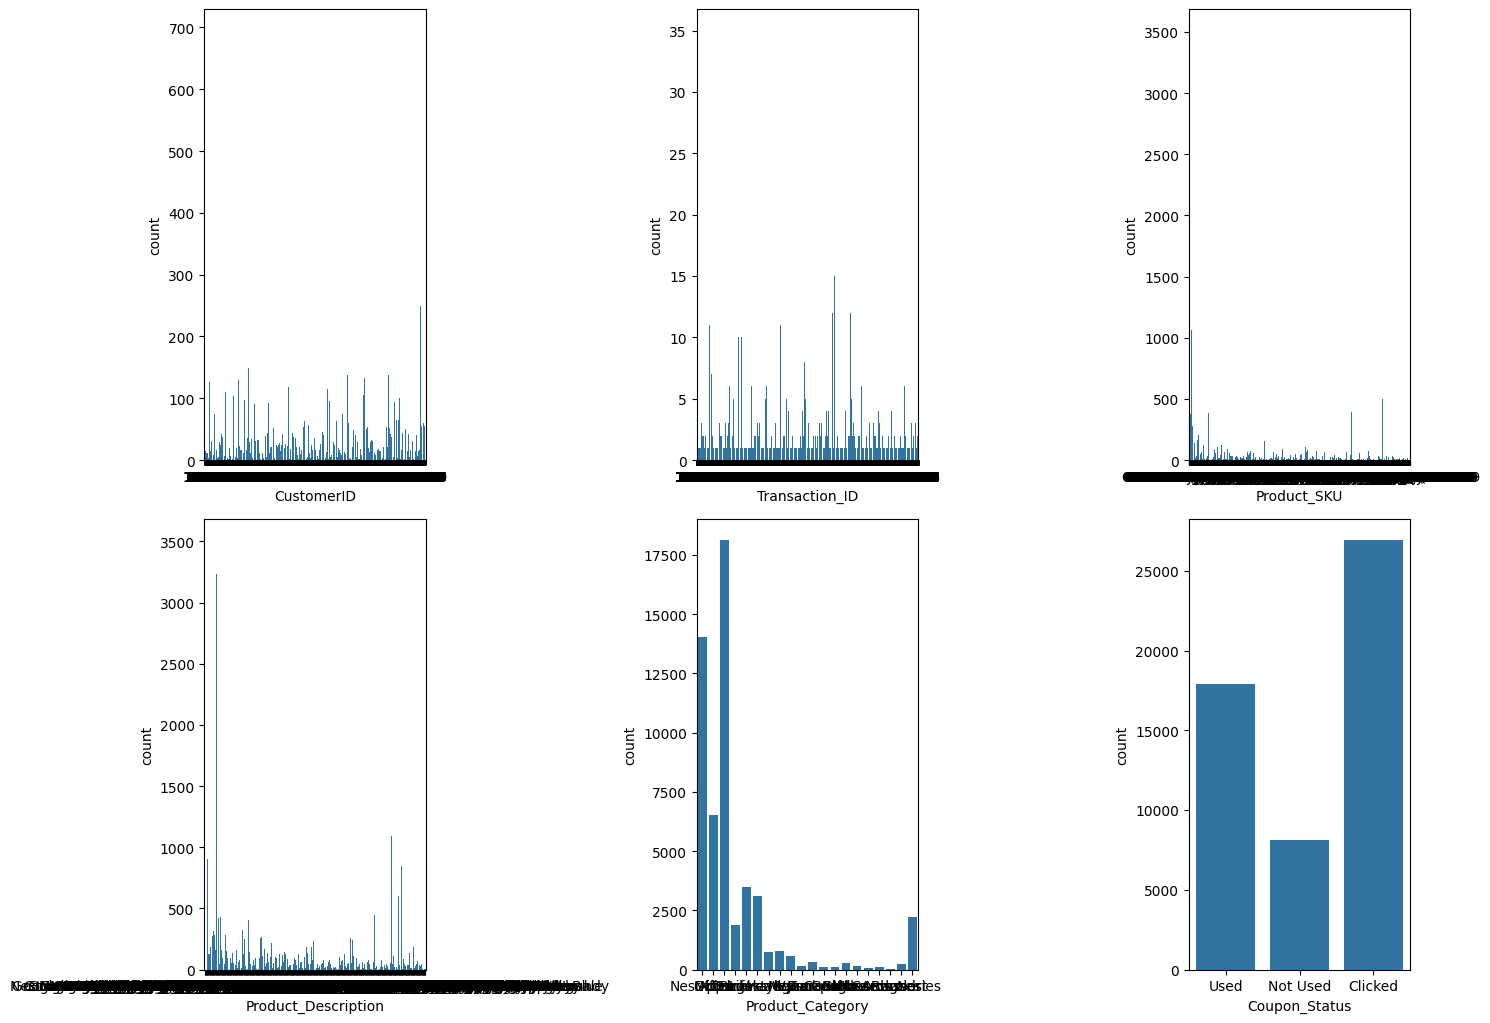

In [ ]:
plt.figure(figsize=(15,15))

for i in range(0,len(var_col)):
  plt.subplot(3,3,i+1)
  sns.countplot(x=onlinesales_df[var_col[i]])
  plt.xlabel(var_col[i])
  plt.tight_layout()

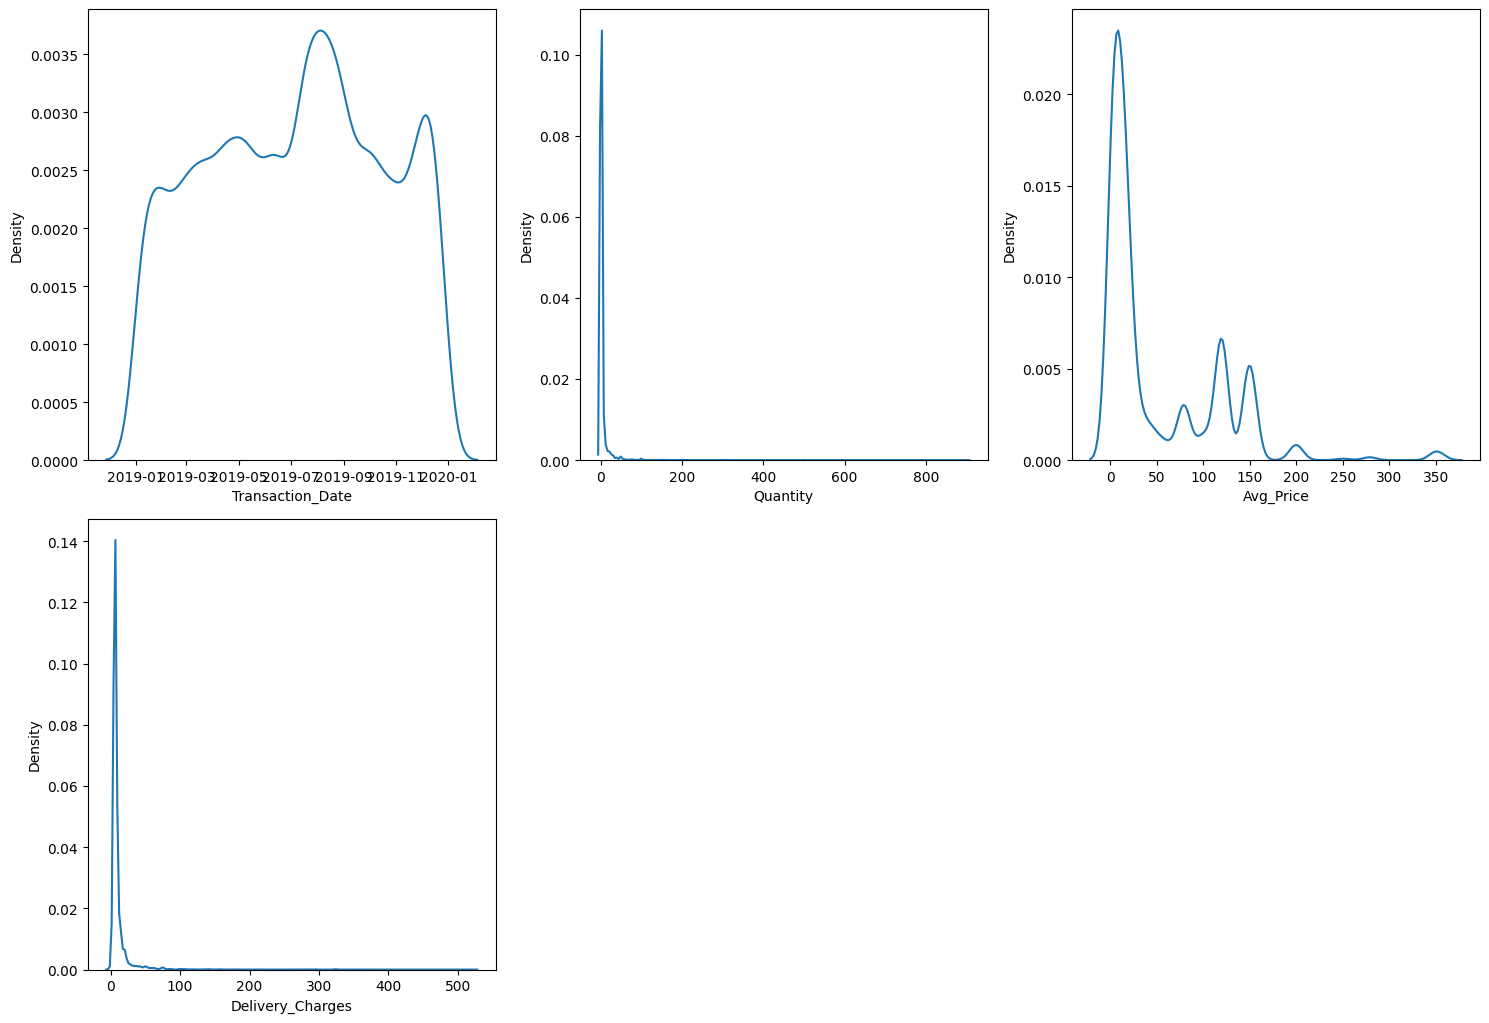

In [ ]:
plt.figure(figsize=(15,15))

for i in range(0,len(num_col)):
  plt.subplot(3,3,i+1)
  sns.kdeplot(x=onlinesales_df[num_col[i]])
  plt.xlabel(num_col[i])
  plt.tight_layout()

# 1. Identify the months with the highest and lowest customer acquisition count. What strategies could be implemented to address the fluctuations and ensure consistent growth throughout the year?  
(datasets: customer_df, discount_df, marketingspend_df, onlinesales_df, taxamount_df)

In [ ]:
#onlinesales_df.head()
# Min date for each customerid
cust_first_txn = onlinesales_df.groupby('CustomerID')['Transaction_Date'].min().reset_index()
cust_first_txn['first_txn_month'] = cust_first_txn['Transaction_Date'].dt.month
cust_first_txn

,CustomerID,Transaction_Date,first_txn_month
0,12346,2019-09-15,9
1,12347,2019-03-24,3
2,12348,2019-06-22,6
3,12350,2019-12-14,12
4,12356,2019-09-15,9
...,...,...,...
1463,18259,2019-04-05,4
1464,18260,2019-06-22,6
1465,18269,2019-04-05,4
1466,18277,2019-10-23,10


In [ ]:
# discount_df # Month	Product_Category	Coupon_Code	Discount_pct
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6, 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
discount_df['month_num'] = discount_df['Month'].map(month_map)
disc = discount_df.groupby(['month_num'])['Discount_pct'].mean().reset_index()
disc

,month_num,Discount_pct
0,1,0.1
1,2,0.2
2,3,0.3
3,4,0.1
4,5,0.2
5,6,0.3
6,7,0.1
7,8,0.2
8,9,0.3
9,10,0.1


In [ ]:
# MOM Offline/Online/Overall marketing spend
marketingspend_df['month'] = marketingspend_df['Date'].dt.month
mark_spend = marketingspend_df.groupby('month')[['Offline_Spend','Online_Spend']].sum().reset_index()
mark_spend['total_spend'] = mark_spend['Offline_Spend'] + mark_spend['Online_Spend']
mark_spend

,month,Offline_Spend,Online_Spend,total_spend
0,1,96600.0,58328.95,154928.95
1,2,81300.0,55807.92,137107.92
2,3,73500.0,48750.09,122250.09
3,4,96000.0,61026.83,157026.83
4,5,65500.0,52759.64,118259.64
5,6,80500.0,53818.14,134318.14
6,7,67500.0,52717.85,120217.85
7,8,85500.0,57404.15,142904.15
8,9,83000.0,52514.54,135514.54
9,10,93500.0,57724.65,151224.65


In [ ]:
# melting offline/online/overall spend into one variable
mark_spend_melt = pd.melt(mark_spend,
        id_vars='month',
        value_vars=['Offline_Spend','Online_Spend','total_spend'],
        var_name='spend_category',
        value_name='spend_value')

In [ ]:
a = cust_first_txn.groupby('first_txn_month')['CustomerID'].nunique().reset_index().rename(columns={'CustomerID':'CustomerCount'})

min_aq = a[a['CustomerCount'] == a['CustomerCount'].min()]
print(f'Lowest customer acquisition count is: {min_aq.iloc[0]['CustomerCount']} in {min_aq.iloc[0]['first_txn_month']}th month')

Lowest customer acquisition count is: 68 in 11th month


In [ ]:
max_aq = a[a['CustomerCount'] == a['CustomerCount'].max()]
print(f'Highest customer acquisition count is: {max_aq.iloc[0]['CustomerCount']} in {max_aq.iloc[0]['first_txn_month']}th month')

Highest customer acquisition count is: 215 in 1th month


Text(0, 0.5, 'Spends')

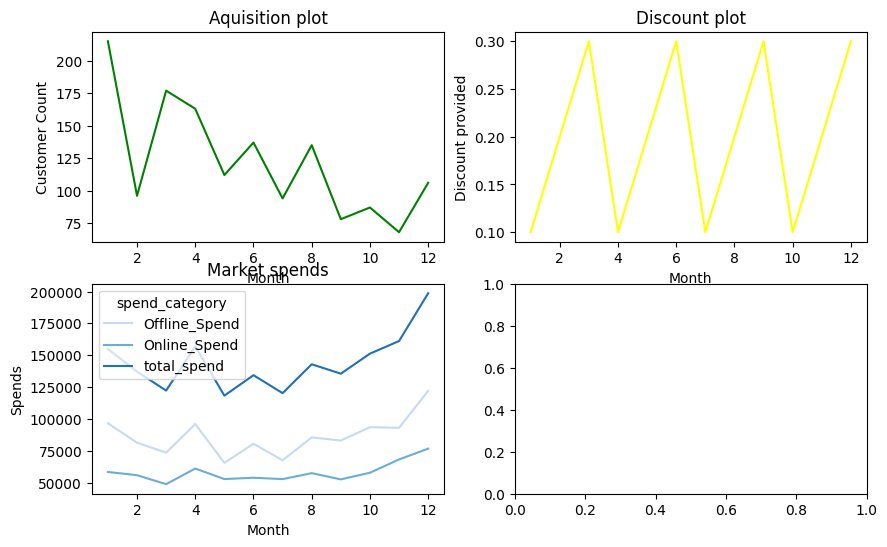

In [ ]:
# plotting customer aquisition mom, discounts mom, marketing spends mom
fig,axes=plt.subplots(2,2,figsize=(10,6))

sns.lineplot(data=a,x='first_txn_month',y='CustomerCount',color='green',ax=axes[0,0])  #aquisition plot
axes[0,0].set_title('Aquisition plot')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Customer Count')

sns.lineplot(data=disc,x='month_num',y='Discount_pct',color='yellow',ax=axes[0,1])     #discount plot
axes[0,1].set_title('Discount plot')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Discount provided')

sns.lineplot(data=mark_spend_melt,x='month',y='spend_value',hue='spend_category',palette='Blues',ax=axes[1,0]) #market spend plot
axes[1,0].set_title('Market spends')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Spends')

Solution 1:

a. Above output are the Lowest and Highest aquisition months.

b. To address the fluctuation in customer aquisition MOM the Marketing spend need to be consistent because as we can see that the marketing spend trend nearly matches the customer aquisition trend.

# Additional Problem: Analyze the data to determine if certain months consistently show higher or lower acquisition. How can the company capitalize on high-performing months and improve performance during slower periods?
(datasets: customer_df, discount_df, marketingspend_df, onlinesales_df, taxamount_df)

In [ ]:
a

,first_txn_month,CustomerCount
0,1,215
1,2,96
2,3,177
3,4,163
4,5,112
5,6,137
6,7,94
7,8,135
8,9,78
9,10,87


In [ ]:
# discount_df # Month	Product_Category	Coupon_Code	Discount_pct
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6, 'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}
discount_df['month_num'] = discount_df['Month'].map(month_map)
disc = discount_df.groupby(['month_num'])['Discount_pct'].mean().reset_index()
disc

,month_num,Discount_pct
0,1,0.1
1,2,0.2
2,3,0.3
3,4,0.1
4,5,0.2
5,6,0.3
6,7,0.1
7,8,0.2
8,9,0.3
9,10,0.1


In [ ]:
# MOM Offline/Online/Overall marketing spend
marketingspend_df['month'] = marketingspend_df['Date'].dt.month
mark_spend = marketingspend_df.groupby('month')[['Offline_Spend','Online_Spend']].sum().reset_index()
mark_spend['total_spend'] = mark_spend['Offline_Spend'] + mark_spend['Online_Spend']
mark_spend

,month,Offline_Spend,Online_Spend,total_spend
0,1,96600.0,58328.95,154928.95
1,2,81300.0,55807.92,137107.92
2,3,73500.0,48750.09,122250.09
3,4,96000.0,61026.83,157026.83
4,5,65500.0,52759.64,118259.64
5,6,80500.0,53818.14,134318.14
6,7,67500.0,52717.85,120217.85
7,8,85500.0,57404.15,142904.15
8,9,83000.0,52514.54,135514.54
9,10,93500.0,57724.65,151224.65


In [ ]:
# melting offline/online/overall spend into one variable
mark_spend_melt = pd.melt(mark_spend,
        id_vars='month',
        value_vars=['Offline_Spend','Online_Spend','total_spend'],
        var_name='spend_category',
        value_name='spend_value')

Text(0, 0.5, 'Spends')

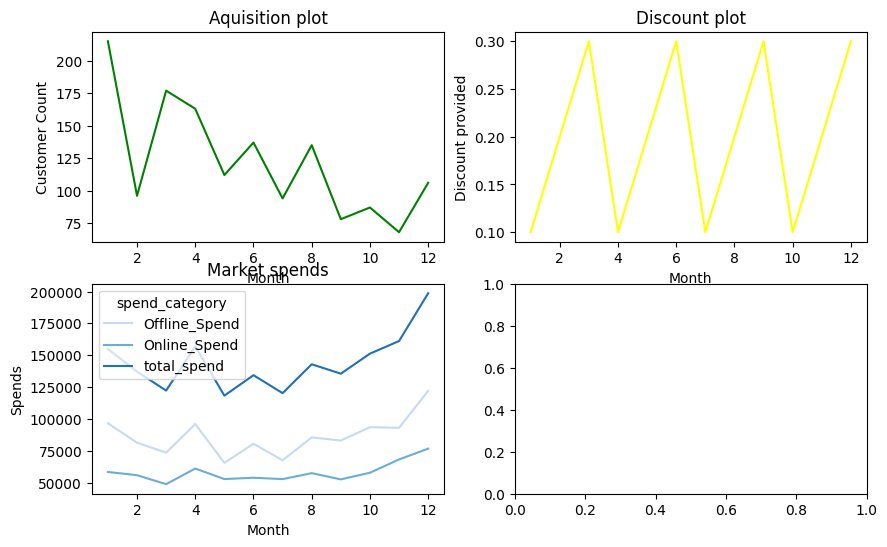

In [ ]:
# plotting customer aquisition mom, discounts mom, marketing spends mom
fig,axes=plt.subplots(2,2,figsize=(10,6))

sns.lineplot(data=a,x='first_txn_month',y='CustomerCount',color='green',ax=axes[0,0])  #aquisition plot
axes[0,0].set_title('Aquisition plot')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Customer Count')

sns.lineplot(data=disc,x='month_num',y='Discount_pct',color='yellow',ax=axes[0,1])     #discount plot
axes[0,1].set_title('Discount plot')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Discount provided')

sns.lineplot(data=mark_spend_melt,x='month',y='spend_value',hue='spend_category',palette='Blues',ax=axes[1,0]) #market spend plot
axes[1,0].set_title('Market spends')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Spends')

Solution 2:

a. As seen from the trend line there is consistent lower acquisition right from March till Dec.

b. And from March to May are consecutive months where lower acquisition is observed.

c. As seen from the trend line there's no such months where consistent higher acquisition is observed

In [ ]:
print(customer_df.shape)
print(discount_df.shape)
print(marketingspend_df.shape)
print(onlinesales_df.shape)
print(taxamount_df.shape)

(1468, 4)
(204, 5)
(365, 4)
(52924, 10)
(20, 2)


Calculating Revenue column:

In [ ]:
# add month number to onlinesales_df
onlinesales_df['month_num'] = onlinesales_df['Transaction_Date'].dt.month
onlinesales_df.head(2)

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,month_num
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1


In [ ]:
# bringing discount column to sales data
onlinesales_df = onlinesales_df.merge(discount_df[['month_num', 'Product_Category', 'Discount_pct']],
                                    on=['month_num','Product_Category'], how='left')

onlinesales_df = onlinesales_df.merge(taxamount_df[['Product_Category', 'GST']],
                                      on='Product_Category', how='left')

In [ ]:
# Revenue(sales) = ((Quantity * Avg_price) * (1 - Discount_pct) * (1 + GST)) + Delivery_Charges.
onlinesales_df.isna().sum()

,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


In [ ]:
onlinesales_df['Discount_pct'] = onlinesales_df['Discount_pct'].fillna(0)

In [ ]:
onlinesales_df.isna().sum()

,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


In [ ]:
print(onlinesales_df['Discount_pct'].value_counts())
print(onlinesales_df['Coupon_Status'].value_counts())

Discount_pct
0.2    17830
0.1    17470
0.3    17224
0.0      400
Name: count, dtype: int64
Coupon_Status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64


In [ ]:
# Revenue(sales) = ((Quantity * Avg_price) * (1 - Discount_pct) * (1 + GST)) + Delivery_Charges.
onlinesales_df.loc[onlinesales_df['Coupon_Status'] == 'Used','revenue'] = (
              onlinesales_df['Quantity'] * onlinesales_df['Avg_Price']) * (1 - onlinesales_df['Discount_pct']) * (1 + onlinesales_df['GST']) + onlinesales_df['Delivery_Charges']


In [ ]:
onlinesales_df.loc[onlinesales_df['Coupon_Status'] != 'Used','revenue'] = (
              onlinesales_df['Quantity'] * onlinesales_df['Avg_Price']) * (1 + onlinesales_df['GST']) + onlinesales_df['Delivery_Charges']


In [ ]:
onlinesales_df.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,month_num,Discount_pct,GST,revenue
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,0.1,0.10,158.6729
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,0.1,0.10,158.6729
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,0.1,0.10,8.5295
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,0.1,0.18,109.9270
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,0.1,0.18,24.0230


# 2. Analyze customer behavior during high-retention months and suggest ways to replicate this success throughout the year.

In [ ]:
onlinesales_df['year_month'] = onlinesales_df['Transaction_Date'].dt.to_period('M')

In [ ]:
monthly_customers = (
onlinesales_df.groupby('year_month')['CustomerID'].apply(set)
)

In [ ]:
result = []

for m in range(2, 13):  # Feb to Dec
    prev_customers = monthly_customers.get(m-1, set())
    curr_customers = monthly_customers.get(m, set())

    pct = (
        len(prev_customers & curr_customers) / len(curr_customers) * 100
        if curr_customers else 0
    )

    result.append({'month': m, 'customer_pct': pct})
result_df = pd.DataFrame(result)

/tmp/ipython-input-139840209.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  prev_customers = monthly_customers.get(m-1, set())
/tmp/ipython-input-139840209.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  curr_customers = monthly_customers.get(m, set())


Text(0, 0.5, 'Retention (%)')

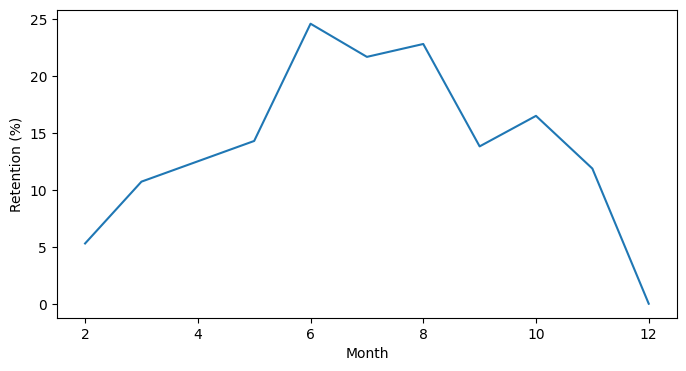

In [ ]:
#result_df
plt.figure(figsize=(8,4))
sns.lineplot(data=result_df,x='month',y='customer_pct')
plt.xlabel('Month')
plt.ylabel('Retention (%)')

Text(0, 0.5, 'Customer Counts using discount')

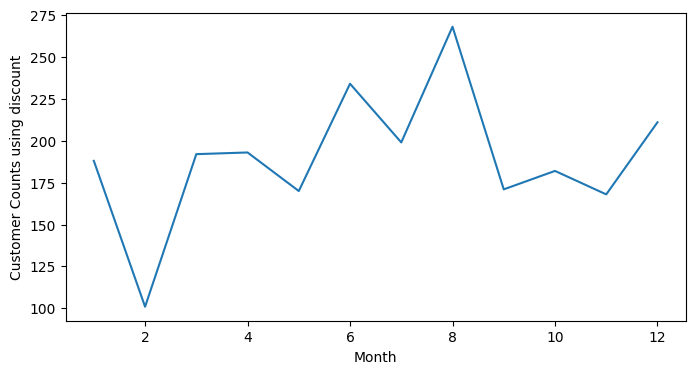

In [ ]:
discounts_used_mom = onlinesales_df[onlinesales_df['Coupon_Status'] == 'Used'].groupby('month_num')['CustomerID'].nunique().reset_index()
plt.figure(figsize=(8,4))
sns.lineplot(data=discounts_used_mom,x='month_num',y='CustomerID')
plt.xlabel('Month')
plt.ylabel('Customer Counts using discount')

Solution 2: The discounts used by customer here as collinearity with retention rates MOM which signifies that the discounts needed to be provided on more products acroos all months.

# 3. Compare the revenue generated by new and existing customers month-over-month. What does this trend suggest about the balance between acquisition and retention efforts?

In [ ]:
first_month = (
onlinesales_df.groupby('CustomerID')['year_month'].min().reset_index(name='first_month')
)
onlinesales_df = onlinesales_df.merge(first_month, on='CustomerID', how='left')

In [ ]:
onlinesales_df['cust_type'] = (
    onlinesales_df['year_month'] == onlinesales_df['first_month']
).map({True: 'New', False: 'Existing'})

In [ ]:
onlinesales_df.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'month_num', 'Discount_pct', 'GST',
       'revenue', 'year_month', 'first_month', 'cust_type'],
      dtype='object')

In [ ]:
year_month_newexis = onlinesales_df.groupby(['year_month','cust_type'])['revenue'].sum().unstack('cust_type').fillna(0).reset_index().sort_values(by=['year_month'],ascending=[True]).reset_index(drop=True)

year_month_newexis['Total_revenue'] = year_month_newexis['Existing'] + year_month_newexis['New']
year_month_newexis['Existing_per'] = year_month_newexis['Existing'] / year_month_newexis['Total_revenue']
year_month_newexis['New_per'] = year_month_newexis['New'] / year_month_newexis['Total_revenue']

year_month_newexis['year_month']=year_month_newexis['year_month'].astype(str)
year_month_newexis

cust_type,year_month,Existing,New,Total_revenue,Existing_per,New_per
0,2019-01,0.00000,494090.54875,494090.54875,0.000000,1.000000
1,2019-02,46524.59322,328637.45408,375162.04730,0.124012,0.875988
2,2019-03,68930.24108,346227.54936,415157.79044,0.166034,0.833966
3,2019-04,195985.88910,281512.70192,477498.59102,0.410443,0.589557
4,2019-05,132338.74688,233257.28268,365596.02956,0.361981,0.638019
5,2019-06,143665.66661,217334.50768,361000.17429,0.397966,0.602034
6,2019-07,271515.72500,180362.68404,451878.40904,0.600860,0.399140
7,2019-08,246913.09862,228883.77692,475796.87554,0.518946,0.481054
8,2019-09,234031.95755,162478.53499,396510.49254,0.590229,0.409771
9,2019-10,223293.20299,257474.16682,480767.36981,0.464452,0.535548


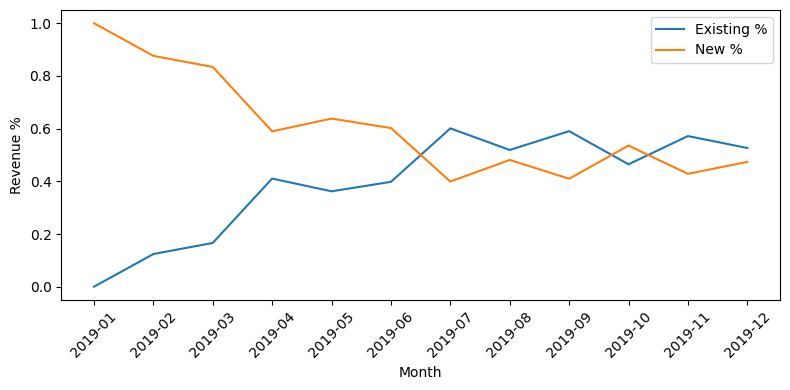

In [ ]:
# plotting new vs repeat revenue contribution
plt.figure(figsize=(8,4))
sns.lineplot(data=year_month_newexis, x='year_month',y='Existing_per',label='Existing %')
sns.lineplot(data=year_month_newexis, x='year_month',y='New_per',label='New %')

plt.xlabel('Month')
plt.ylabel('Revenue %')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Solution 3: Revenue generated by New & Existing tell us that linear growth of existing customers and linear decline of new customers. That means customer aquisition is also dropping by time. But July onwards the contribution in revenue is fairly equal and the staright line that means the discounts plot we seen earlier showing effect here and more discounts needs to be implimented on transactions.

# 4. Identify the top-performing products and analyze the factors driving their success. How can this insight inform inventory management and promotional strategies?

In [ ]:
# top performing products in qty and revenue terms
# (Product_Category, Product_Descriptionx)
product_performance = onlinesales_df.groupby(['Product_Category'])[['revenue','Quantity']].sum().reset_index().round(2).sort_values(by='revenue',ascending=False).reset_index(drop=True)
product_performance['avg_product_price'] = product_performance['revenue'] / product_performance['Quantity']

product_performance

,Product_Category,revenue,Quantity,avg_product_price
0,Nest-USA,2721645.76,21430,127.001669
1,Apparel,827829.21,32438,25.520353
2,Nest,520653.67,2837,183.522619
3,Office,381945.27,88383,4.321479
4,Drinkware,272621.96,30501,8.938132
5,Bags,193626.61,15273,12.677706
6,Lifestyle,125276.00,24881,5.035007
7,Notebooks & Journals,122419.32,9556,12.810728
8,Nest-Canada,76245.76,469,162.570917
9,Headgear,57861.49,3533,16.377438


Solution 4: Top performing Product category is Nest-USA, Apparel and Nest in terms of revenue. And Office, Apparel and Drinkware categories in terms of quantity sold. They are because there is discount applied and customers have used it over the months.

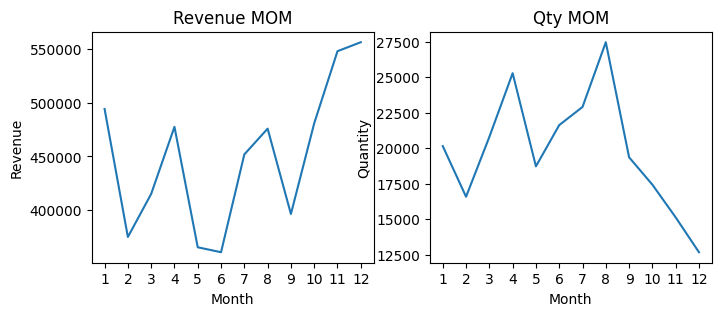

In [ ]:
mom_rev_qty = onlinesales_df.groupby('month_num')[['revenue','Quantity']].sum().reset_index()

fig,axes = plt.subplots(1,2,figsize=(8,3))

sns.lineplot(data=mom_rev_qty, x='month_num',y='revenue',ax=axes[0])
axes[0].set_title('Revenue MOM')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')
axes[0].set_xticks(range(1, 13))

sns.lineplot(data=mom_rev_qty, x='month_num',y='Quantity',ax=axes[1])
axes[1].set_title('Qty MOM')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Quantity')
axes[1].set_xticks(range(1, 13))

plt.show()

Solution 4: a. Top performing Product category is Nest-USA, Apparel and Nest in terms of revenue. And Office, Apparel and Drinkware categories in terms of quantity sold. They are because there is discount applied and customers have used it over the months.

b. As we can see the Revenue MOM plot the sales are spiking up right from 9th month but from Qunatity MOM plot the is dipping significantly from 9th month, so there is scope of more revenue generation 9th month onwards if inventory is filled. And before 9th month the trend line is similar so offcourse the consisitent supply of inventory is needed to cover the demand.

# 5. Segment customers into groups such as Premium, Gold, Silver, and Standard. What targeted strategies can be developed for each segment to improve retention and revenue? (Use RFM segmentation techniques)

In [ ]:
# Max date '2019-12-31'
cust_trans = onlinesales_df.groupby('CustomerID').agg(
                                          last_txn_date=('Transaction_Date','max'),
                                          Frequency=('Transaction_Date','nunique'),
                                          Monetary =('revenue','sum')
                                          ).reset_index()

In [ ]:
cust_trans['Recency'] = (pd.Timestamp.today() - cust_trans['last_txn_date']).dt.days

In [ ]:
cust_trans[['Frequency','Monetary','Recency']].describe()

,Frequency,Monetary,Recency
count,1468.000000,1468.000000,1468.000000
mean,2.185286,3676.674895,2373.292234
std,2.235245,5846.082106,101.936959
min,1.000000,6.990000,2229.000000
25%,1.000000,783.974310,2284.000000
50%,1.500000,2011.622610,2360.000000
75%,3.000000,4495.056630,2449.000000
max,34.000000,87200.896260,2593.000000


In [ ]:
rec = cust_trans['Recency'].quantile([0.25,0.50,0.75])
freq = cust_trans['Frequency'].quantile([0.25,0.50,0.75])
mone = cust_trans['Monetary'].quantile([0.25,0.50,0.75])
#cust_trans['Frequency'].quantile([0.25,0.50,0.75])
#cust_trans['Monetary'].quantile([0.25,0.50,0.75])

In [ ]:
cust_trans['recency_score'] = pd.cut(cust_trans['Recency'], bins=[-float('inf'),rec[0.25],rec[0.50],rec[0.75],float('inf')],
                                   labels=[4,3,2,1])

cust_trans['frequency_score'] = pd.cut(cust_trans['Frequency'], bins=[-float('inf'),freq[0.25],freq[0.50],freq[0.75],float('inf')],
                                   labels=[1,2,3,4])

cust_trans['monetary_score'] = pd.cut(cust_trans['Monetary'], bins=[-float('inf'),mone[0.25],mone[0.50],mone[0.75],float('inf')],
                                   labels=[1,2,3,4])
cust_trans['recency_score'] = cust_trans['recency_score'].astype('int')
cust_trans['frequency_score'] = cust_trans['frequency_score'].astype('int')
cust_trans['monetary_score'] = cust_trans['monetary_score'].astype('int')
cust_trans['RFM_Score'] = cust_trans['monetary_score'] + cust_trans['recency_score'] + cust_trans['monetary_score']

In [ ]:
cust_trans.isnull().sum()

,0
CustomerID,0
last_txn_date,0
Frequency,0
Monetary,0
Recency,0
recency_score,0
frequency_score,0
monetary_score,0
RFM_Score,0


In [ ]:
cust_trans.describe()

,CustomerID,last_txn_date,Frequency,Monetary,Recency,recency_score,frequency_score,monetary_score,RFM_Score
count,1468.000000,1468,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000,1468.000000
mean,15314.386240,2019-08-08 16:59:10.953678336,2.185286,3676.674895,2373.292234,2.506812,2.142371,2.500000,7.506812
min,12346.000000,2019-01-01 00:00:00,1.000000,6.990000,2229.000000,1.000000,1.000000,1.000000,3.000000
25%,13830.500000,2019-05-25 00:00:00,1.000000,783.974310,2284.000000,2.000000,1.000000,1.750000,5.000000
50%,15300.000000,2019-08-22 00:00:00,1.500000,2011.622610,2360.000000,3.000000,2.000000,2.500000,7.000000
75%,16882.250000,2019-11-06 00:00:00,3.000000,4495.056630,2449.000000,4.000000,3.000000,3.250000,10.000000
max,18283.000000,2019-12-31 00:00:00,34.000000,87200.896260,2593.000000,4.000000,4.000000,4.000000,12.000000
std,1744.000367,NaN,2.235245,5846.082106,101.936959,1.119004,1.186508,1.118415,2.751827


In [ ]:
cust_trans['RFM_Tag'] = pd.cut(cust_trans['RFM_Score'], bins=[0,3,6,9,12],
                                   labels=['Standard','Silver','Premium','Gold'])

In [ ]:
cust_trans.sample(3)

,CustomerID,last_txn_date,Frequency,Monetary,Recency,recency_score,frequency_score,monetary_score,RFM_Score,RFM_Tag
1373,17889,2019-10-05,1,1167.50736,2316,3,1,2,7,Premium
1289,17591,2019-11-03,4,6767.22968,2287,3,4,4,11,Gold
1233,17373,2019-11-28,1,2136.84596,2262,4,1,3,10,Gold


In [ ]:
cust_trans.isnull().sum()

,0
CustomerID,0
last_txn_date,0
Frequency,0
Monetary,0
Recency,0
recency_score,0
frequency_score,0
monetary_score,0
RFM_Score,0
RFM_Tag,0


In [ ]:
cust_trans.groupby('RFM_Tag')['CustomerID'].nunique().reset_index().sort_values(by='CustomerID',ascending=False).reset_index(drop=True)

/tmp/ipython-input-2515521649.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cust_trans.groupby('RFM_Tag')['CustomerID'].nunique().reset_index().sort_values(by='CustomerID',ascending=False).reset_index(drop=True)


,RFM_Tag,CustomerID
0,Premium,474
1,Silver,451
2,Gold,421
3,Standard,122


Solution 5: a. Customers Groups are created basis their Recency/Frequency/Monetary quantile distribution(4 equal quantiles).
b. More offers can be provide to Silver and Standard customers to retain them and focussing more marketing efforts can be done here to create more revenue from Premium and Gold customers.

# 6. Analyze the revenue contribution of each customer segment. How can the company focus its efforts on high-value segments while nurturing lower-value segments?

In [ ]:
#cust_trans['month'] =
a = cust_trans['Monetary'].sum()
Revenue_contri_Sements = round(cust_trans.groupby('RFM_Tag')['Monetary'].sum().reset_index().sort_values(by='Monetary',ascending=False).reset_index(drop=True),2)
Revenue_contri_Sements['Contribution_Per'] = round((Revenue_contri_Sements['Monetary'] / a),2)
Revenue_contri_Sements

/tmp/ipython-input-316172608.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Revenue_contri_Sements = round(cust_trans.groupby('RFM_Tag')['Monetary'].sum().reset_index().sort_values(by='Monetary',ascending=False).reset_index(drop=True),2)


,RFM_Tag,Monetary,Contribution_Per
0,Gold,3503283.26,0.65
1,Premium,1493133.43,0.28
2,Silver,363589.75,0.07
3,Standard,37352.30,0.01


In [ ]:
onlinesales_copy = onlinesales_df.merge(cust_trans, on=['CustomerID'], how='left')
onlinesales_copy.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'month_num', 'Discount_pct', 'GST',
       'revenue', 'year_month', 'first_month', 'cust_type', 'last_txn_date',
       'Frequency', 'Monetary', 'Recency', 'recency_score', 'frequency_score',
       'monetary_score', 'RFM_Score', 'RFM_Tag'],
      dtype='object')

/tmp/ipython-input-2928141195.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_trans_mom = onlinesales_copy.groupby(['month_num','RFM_Tag'])['CustomerID'].nunique().reset_index().sort_values(by='month_num')


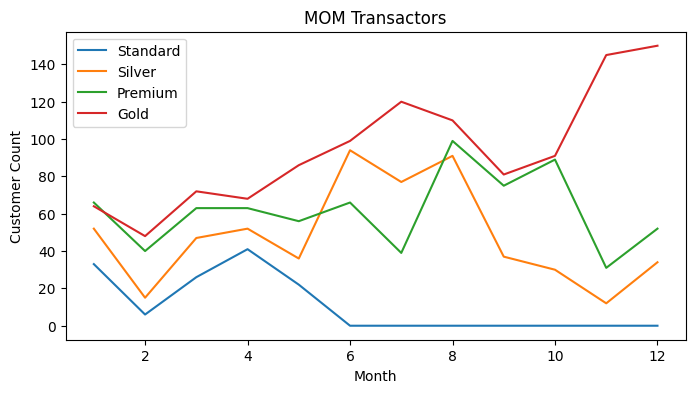

In [ ]:
seg_trans_mom = onlinesales_copy.groupby(['month_num','RFM_Tag'])['CustomerID'].nunique().reset_index().sort_values(by='month_num')

plt.figure(figsize=(8,4))

sns.lineplot(data=seg_trans_mom, x='month_num', y='CustomerID', hue='RFM_Tag', legend='auto')
plt.title('MOM Transactors')
plt.xlabel('Month')
plt.ylabel('Customer Count')
plt.legend()
plt.show()

Solution 6: a. High value customers are bringing nearly 93% of the revenue which means retention here plays much crucial role than in any other segment. And also from above trend line, MOM Gold segment transactors are increasing.
But premium customers are not cosistent.

b. And the Low value customers which contributes to sum 7%, we can reatin them by providing more discounts across all months. From trend line we can see Standard and Silver segment transactor declining MOM.

# 7. Group customers by their month of first purchase and analyze retention rates over time. Which cohorts exhibit the highest and lowest retention rates? What strategies can be implemented to improve retention for weaker cohorts?

In [ ]:
#onlinesales_df.head(5)
cust_first_txn = onlinesales_df[['first_month','CustomerID']]
cust_first_txn = cust_first_txn[['first_month','CustomerID']].drop_duplicates()
cust_first_txn.shape

(1468, 2)

In [ ]:
cust_all_txn = onlinesales_df[['Transaction_Date','CustomerID']]
cust_all_txn['txn_yr_month'] = cust_all_txn['Transaction_Date'].dt.to_period('M')
cust_all_txn.shape

/tmp/ipython-input-603101708.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cust_all_txn['txn_yr_month'] = cust_all_txn['Transaction_Date'].dt.to_period('M')


(52924, 3)

In [ ]:
#cust_first_txn #, cust_all_txn
cust_cohort_data = cust_all_txn.merge(cust_first_txn,on='CustomerID',how='inner')
cust_cohort_data.shape

(52924, 4)

In [ ]:
cust_cohort_data['Cohort_Index'] = (
    (cust_cohort_data['txn_yr_month'].dt.year - cust_cohort_data['first_month'].dt.year) * 12 +
    (cust_cohort_data['txn_yr_month'].dt.month - cust_cohort_data['first_month'].dt.month)
)
cust_cohort_data


,Transaction_Date,CustomerID,txn_yr_month,first_month,Cohort_Index
0,2019-01-01,17850,2019-01,2019-01,0
1,2019-01-01,17850,2019-01,2019-01,0
2,2019-01-01,17850,2019-01,2019-01,0
3,2019-01-01,17850,2019-01,2019-01,0
4,2019-01-01,17850,2019-01,2019-01,0
...,...,...,...,...,...
52919,2019-12-31,14410,2019-12,2019-12,0
52920,2019-12-31,14410,2019-12,2019-12,0
52921,2019-12-31,14410,2019-12,2019-12,0
52922,2019-12-31,14600,2019-12,2019-12,0


In [ ]:
cohort_data = (cust_cohort_data.groupby(['first_month', 'Cohort_Index'])['CustomerID'].nunique().reset_index())

In [ ]:
cohort_table = cohort_data.pivot(index='first_month',columns='Cohort_Index',values='CustomerID')
retention = cohort_table.divide(cohort_table[0], axis=0)
retention

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2019-01,1.0,0.060465,0.111628,0.158140,0.106977,0.204651,0.162791,0.218605,0.106977,0.130233,0.093023,0.15814
2019-02,1.0,0.072917,0.093750,0.166667,0.177083,0.229167,0.197917,0.156250,0.125000,0.114583,0.166667,NaN
2019-03,1.0,0.101695,0.197740,0.141243,0.180791,0.186441,0.124294,0.124294,0.084746,0.107345,NaN,NaN
2019-04,1.0,0.085890,0.147239,0.147239,0.110429,0.092025,0.061350,0.098160,0.073620,NaN,NaN,NaN
2019-05,1.0,0.107143,0.080357,0.116071,0.089286,0.116071,0.125000,0.071429,NaN,NaN,NaN,NaN
2019-06,1.0,0.145985,0.160584,0.087591,0.080292,0.102190,0.080292,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.138298,0.042553,0.063830,0.117021,0.095745,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.103704,0.111111,0.074074,0.059259,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,1.0,0.076923,0.038462,0.025641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Solution 7: September month cohort has lowest retention rate in Dec (2.56%) and February month cohort has highest retention rate in July (22.91%). We can focus on all segments other than Gold segment customers retention rate by focusing on regulating more offer to them.

# 9. Identify seasonal trends in sales by category and location. How can the company prepare for peak and off-peak seasons to maximize revenue?

In [ ]:
# Product_Category (20)
len(onlinesales_df['Product_Category'].value_counts())

20

In [ ]:
onlinesales_df_copy = onlinesales_df.merge(customer_df[['CustomerID','Location']], on ='CustomerID', how='left')
onlinesales_df_copy.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,month_num,Discount_pct,GST,revenue,year_month,first_month,cust_type,Location
0,17850,16679,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,0.1,0.10,158.6729,2019-01,2019-01,New,Chicago
1,17850,16680,2019-01-01,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.5,Used,1,0.1,0.10,158.6729,2019-01,2019-01,New,Chicago
2,17850,16681,2019-01-01,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.5,Used,1,0.1,0.10,8.5295,2019-01,2019-01,New,Chicago
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.5,Not Used,1,0.1,0.18,109.9270,2019-01,2019-01,New,Chicago
4,17850,16682,2019-01-01,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.5,Used,1,0.1,0.18,24.0230,2019-01,2019-01,New,Chicago


In [ ]:
cat_rev_mom = onlinesales_df_copy.groupby(['Location','Product_Category','month_num'])['revenue'].mean().reset_index()
cat_rev_mom

,Location,Product_Category,month_num,revenue
0,California,Accessories,5,20.950100
1,California,Accessories,6,43.811660
2,California,Accessories,7,645.330333
3,California,Accessories,8,24.526400
4,California,Accessories,9,223.018883
...,...,...,...,...
885,Washington DC,Waze,8,14.377410
886,Washington DC,Waze,9,14.734200
887,Washington DC,Waze,10,170.180790
888,Washington DC,Waze,11,41.658656


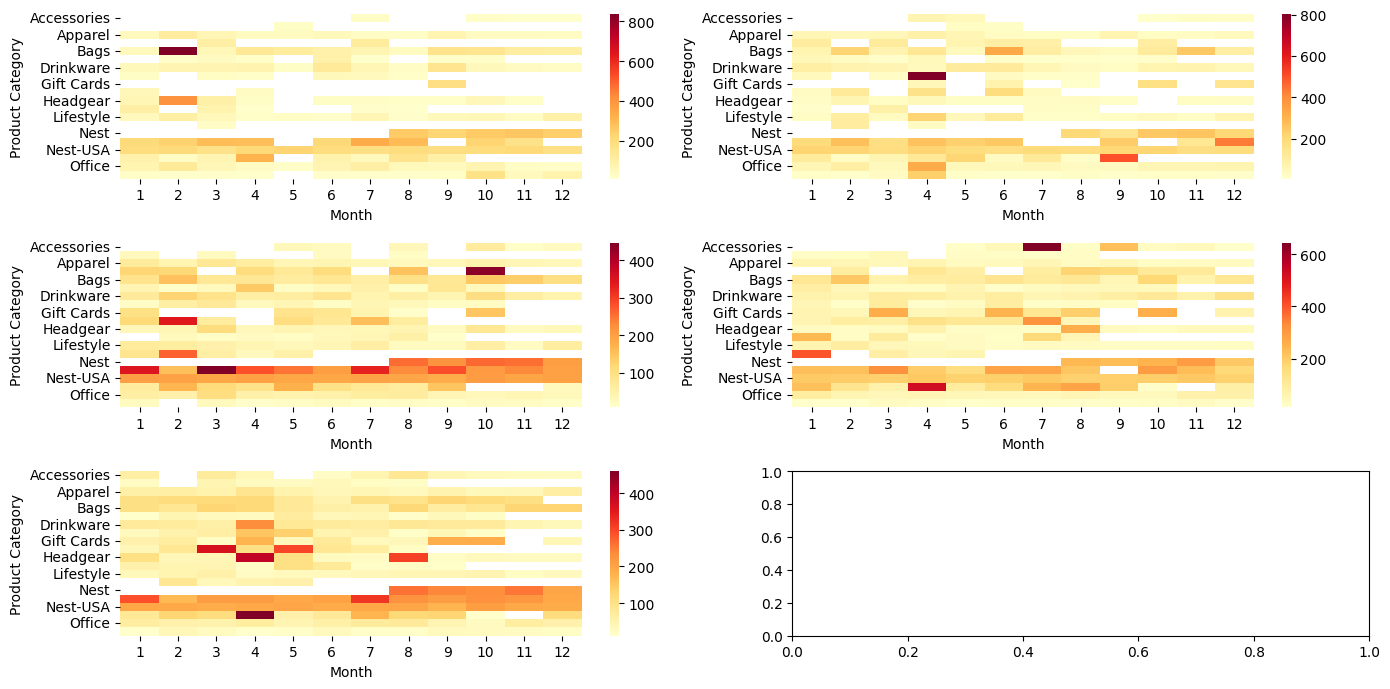

In [ ]:
fig , axes =plt.subplots(3,2,figsize=(14,7))

heatmap_data_1 = (cat_rev_mom[cat_rev_mom['Location'] == 'Washington DC'].pivot(index='Product_Category', columns='month_num', values='revenue'))
sns.heatmap(heatmap_data_1,cmap='YlOrRd',ax=axes[0,0])#,linewidths=0.5)
#axes[0,1].set_title(f'Seasonal Sales Trend by Category – {location}')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Product Category')

heatmap_data_2 = (cat_rev_mom[cat_rev_mom['Location'] == 'New Jersey'].pivot(index='Product_Category', columns='month_num', values='revenue'))
sns.heatmap(heatmap_data_2,cmap='YlOrRd',ax=axes[0,1])#,linewidths=0.5)
#axes[0,1].set_title(f'Seasonal Sales Trend by Category – {location}')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Product Category')

heatmap_data_3 = (cat_rev_mom[cat_rev_mom['Location'] == 'New York'].pivot(index='Product_Category', columns='month_num', values='revenue'))
sns.heatmap(heatmap_data_3,cmap='YlOrRd',ax=axes[1,0])#,linewidths=0.5)
#axes[0,1].set_title(f'Seasonal Sales Trend by Category – {location}')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Product Category')

heatmap_data_4 = (cat_rev_mom[cat_rev_mom['Location'] == 'California'].pivot(index='Product_Category', columns='month_num', values='revenue'))
sns.heatmap(heatmap_data_4,cmap='YlOrRd',ax=axes[1,1])#,linewidths=0.5)
#axes[0,1].set_title(f'Seasonal Sales Trend by Category – {location}')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Product Category')

heatmap_data_5 = (cat_rev_mom[cat_rev_mom['Location'] == 'Chicago'].pivot(index='Product_Category', columns='month_num', values='revenue'))
sns.heatmap(heatmap_data_5,cmap='YlOrRd',ax=axes[2,0])#,linewidths=0.5)
#axes[0,1].set_title(f'Seasonal Sales Trend by Category – {location}')
axes[2,0].set_xlabel('Month')
axes[2,0].set_ylabel('Product Category')

plt.tight_layout()
plt.show()


Solution 9: As seen from the trend Nest-USA category is in demand all over the year in majorly all locations. And mostly April month is peak season for majorly all locations.

# 10. Analyze daily sales trends to identify high-performing and low-performing days. What strategies can be implemented to boost sales on slower days?

(array([17897., 17956., 18017., 18078., 18140., 18201., 18262.]),
 [Text(17897.0, 0, '2019-01'),
  Text(17956.0, 0, '2019-03'),
  Text(18017.0, 0, '2019-05'),
  Text(18078.0, 0, '2019-07'),
  Text(18140.0, 0, '2019-09'),
  Text(18201.0, 0, '2019-11'),
  Text(18262.0, 0, '2020-01')])

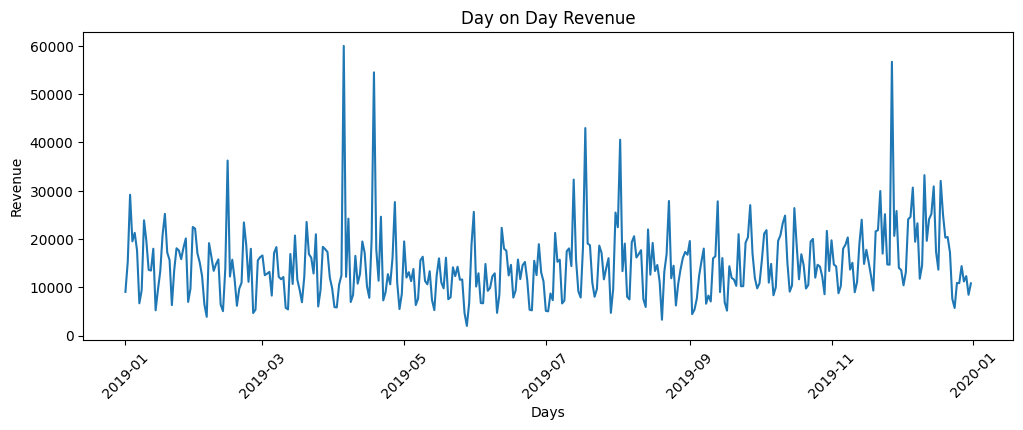

In [ ]:
#onlinesales_df.head()
plt.figure(figsize=(12,4))

dod_sales = onlinesales_df.groupby('Transaction_Date')['revenue'].sum().reset_index().sort_values(by='Transaction_Date',ascending=True)

sns.lineplot(data=dod_sales, x='Transaction_Date', y='revenue')
plt.title('Day on Day Revenue')
plt.xlabel('Days')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

Solution 10: There's only little deviation from base line trend at the end of the year as compared to rest days of the year.And only few spikes on selective which are seasonal.